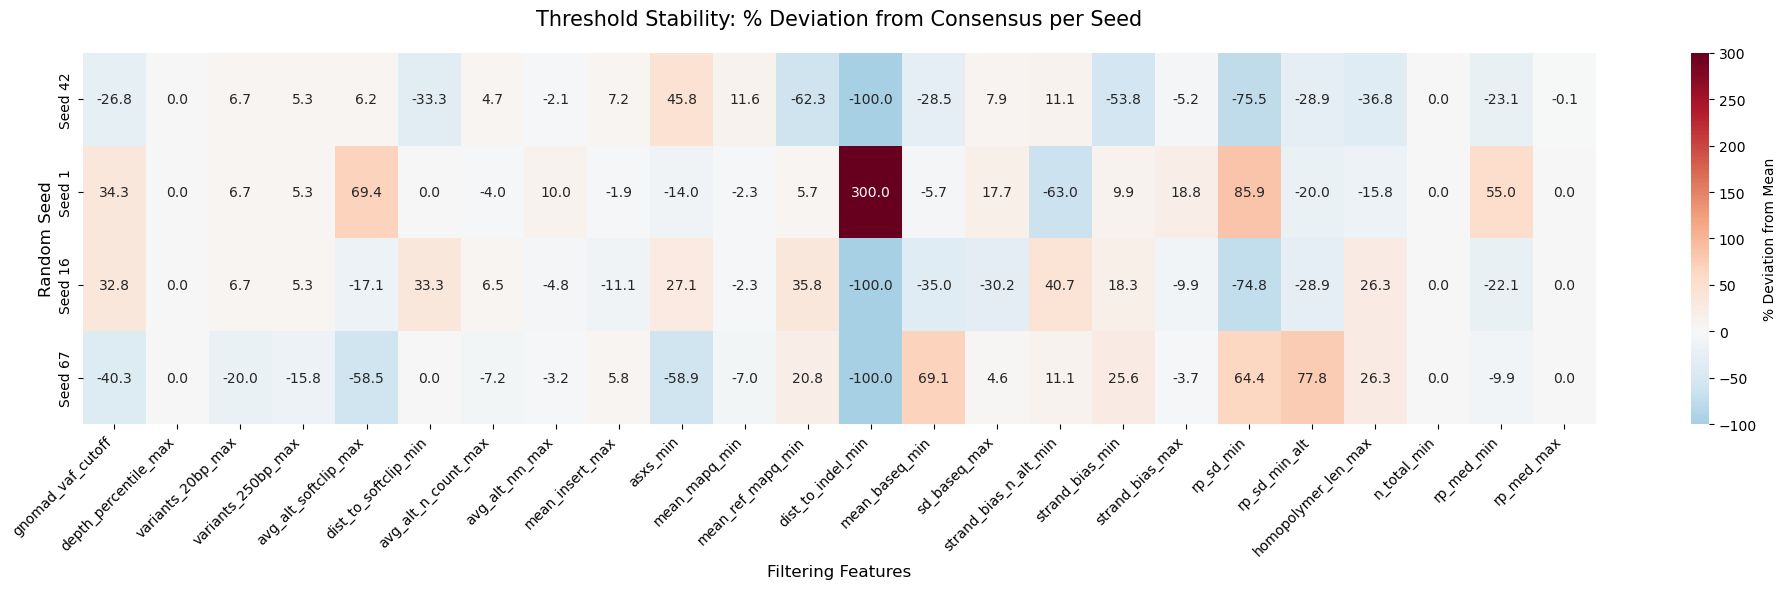

--- STABILITY RANKING ---
Lower score = more consistent across seeds
depth_percentile_max     0.000000
n_total_min              0.000000
rp_med_max               0.000802
avg_alt_n_count_max      0.066347
avg_alt_nm_max           0.067888
mean_mapq_min            0.080561
mean_insert_max          0.084253
variants_250bp_max       0.105263
strand_bias_max          0.127776
variants_20bp_max        0.133333
sd_baseq_max             0.209154
dist_to_softclip_min     0.272166
homopolymer_len_max      0.315789
strand_bias_min          0.364379
rp_med_min               0.371371
gnomad_vaf_cutoff        0.391228
mean_ref_mapq_min        0.433004
strand_bias_n_alt_min    0.442382
asxs_min                 0.465292
mean_baseq_min           0.477488
rp_sd_min_alt            0.520209
avg_alt_softclip_max     0.534468
rp_sd_min                0.872185
dist_to_indel_min        2.000000
dtype: float64


In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
# Add any column names here that you want to hide from the heatmap
EXCLUDE_FEATURES = [
    'sd_insert_max', 
    'germline_vaf_max', 
    'cord_penalty_weight',
]

files = [
    'training_results/best_thresholds.json', 
    'training_results_seed_1/best_thresholds.json', 
    'training_results_seed_16/best_thresholds.json', 
    'training_results_seed_67/best_thresholds.json'
] 

# 1. Load and Flatten Data
data_list = []
for f in files:
    with open(f, 'r') as j:
        d = json.load(j)
        flat_d = d['thresholds'].copy()
        flat_d['use_cord_pon'] = d['pon_flags']['use_cord_pon']
        flat_d['blacklists_enforced'] = d['blacklists_enforced']
        flat_d['cord_penalty_weight'] = d['cord_penalty_weight']
        data_list.append(flat_d)

df = pd.DataFrame(data_list)
df.index = ["Seed 42", "Seed 1", "Seed 16", "Seed 67"]

# 2. Filtering & Calculation
# Drop excluded features and ensure we only have numbers
numeric_df = df.drop(columns=[c for c in EXCLUDE_FEATURES if c in df.columns])
numeric_df = numeric_df.select_dtypes(include=[np.number])

# Calculate Mean and % Deviation
mean_vals = numeric_df.mean()
# Using .replace(0, 1) to avoid division by zero for features that are always 0
pct_dev = ((numeric_df - mean_vals) / mean_vals.replace(0, 1)) * 100

# 3. Plotting
plt.figure(figsize=(20, 6))

# RdBu_r: Red is higher than mean, Blue is lower than mean, White is consensus
sns.heatmap(pct_dev, 
            annot=True, 
            fmt=".1f", 
            cmap="RdBu_r", 
            center=0, 
            cbar_kws={'label': '% Deviation from Mean'})

plt.title("Threshold Stability: % Deviation from Consensus per Seed", fontsize=15, pad=20)
plt.ylabel("Random Seed", fontsize=12)
plt.xlabel("Filtering Features", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Consistency Summary
# Using Coefficient of Variation (std/mean) as a stability score
stability_score = (numeric_df.std() / numeric_df.mean().replace(0, 1)).sort_values()
print("--- STABILITY RANKING ---")
print("Lower score = more consistent across seeds")
print(stability_score)

### Performance Stability Summary ###


,mean,std,min,max,cv_%
train_perf,2361.25,27.6451,2337.0,2400.0,1.1708
val_perf,1756.75,38.0121,1706.0,1798.0,2.1638


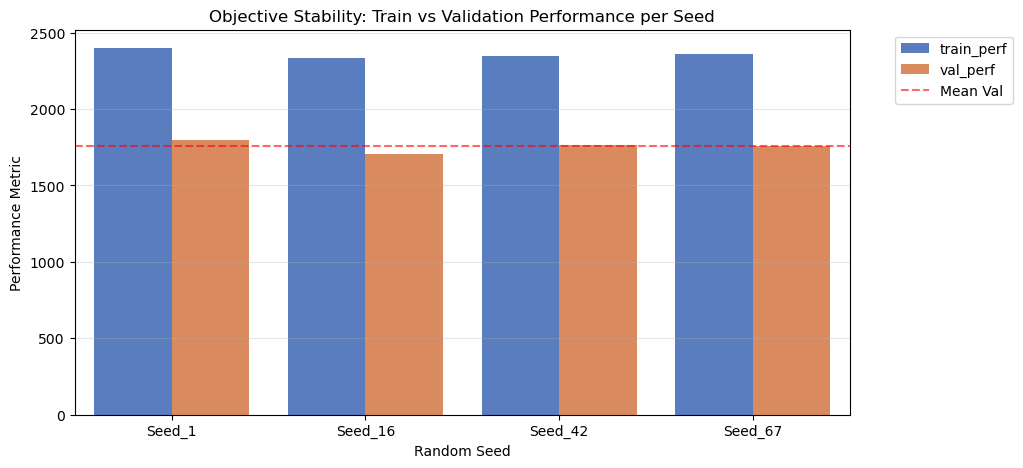


### Threshold Sensitivity (Correlation with Val Performance) ###
High positive/negative values suggest this threshold strongly drives the results.


,Correlation with Val_Perf
rp_med_min,NaN
rp_med_max,NaN
use_cord_pon,NaN
blacklists_enforced,NaN
cord_penalty_weight,NaN


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- MANUAL ENTRY SECTION ---
# Update these values with your recorded results
performance_records = {
    "Seed_1": {"train_perf": 2400, "val_perf": 1798},
    "Seed_16": {"train_perf": 2337, "val_perf": 1706},
    "Seed_42": {"train_perf": 2347, "val_perf": 1764},
    "Seed_67": {"train_perf": 2361, "val_perf": 1759}, # Add as you go
}

# 1. Convert to DataFrame
perf_df = pd.DataFrame.from_dict(performance_records, orient='index')

# 2. Join with your thresholds dataframe (from previous step)
# This assumes 'df' exists from the first cell
full_analysis_df = df.join(perf_df)

# 3. Calculate Stability Metrics for Performance
perf_stats = perf_df.agg(['mean', 'std', 'min', 'max']).T
perf_stats['cv_%'] = (perf_stats['std'] / perf_stats['mean']) * 100

print("### Performance Stability Summary ###")
display(perf_stats.round(4))

# 4. Visualize Performance Gap (Overfitting Check)
plt.figure(figsize=(10, 5))
tidy_perf = perf_df.reset_index().melt(id_vars='index', var_name='Split', value_name='Score')
sns.barplot(data=tidy_perf, x='index', y='Score', hue='Split', palette='muted')

# Add a reference line for the mean validation performance
plt.axhline(perf_df['val_perf'].mean(), color='red', linestyle='--', alpha=0.6, label='Mean Val')

plt.title("Objective Stability: Train vs Validation Performance per Seed")
#plt.ylim(perf_df.values.min() - 0.05, 1.0) # Zoom in to see differences
plt.ylabel("Performance Metric")
plt.xlabel("Random Seed")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 5. Correlation Check: Do "extreme" thresholds lead to better performance?
# We check if validation performance correlates with any specific threshold
correlations = full_analysis_df.corr()['val_perf'].drop(['val_perf', 'train_perf']).sort_values()

print("\n### Threshold Sensitivity (Correlation with Val Performance) ###")
print("High positive/negative values suggest this threshold strongly drives the results.")
display(correlations.to_frame(name='Correlation with Val_Perf').tail(5)) # Top 5 drivers